In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru scikit-learn

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            # Move annotations to expected location
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 684, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 684 (delta 55), reused 103 (delta 53), pack-reused 561 (from 2)
Receiving objects: 100% (684/684), 94.51 MiB | 55.59 MiB/s, done.
Resolving deltas: 100% (388/388), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 12.79 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Processed Data from Substep 1

In [3]:
# Load data from Substep 1
DATA_PATH = "extension_data/step_embeddings_gt.pkl"

if IN_COLAB:
    DRIVE_DATA_PATH = "/content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl"
    if os.path.exists(DRIVE_DATA_PATH):
        DATA_PATH = DRIVE_DATA_PATH

if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'rb') as f:
        loaded_data = pickle.load(f)

    processed_data = loaded_data['data']
    splits = loaded_data['splits']
    print(f"Loaded {len(processed_data)} recordings")
else:
    print(f"Data not found at {DATA_PATH}")
    print("Please run extension_step1_localization.ipynb first!")

Loaded 383 recordings


In [4]:
# Get feature dimension from data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Feature dimension: {FEATURE_DIM}")

# Group recordings by recipe type
recipe_groups = defaultdict(list)
for recording_id, data in processed_data.items():
    recipe_id = data['recipe_id']
    recipe_groups[recipe_id].append(recording_id)

print(f"\nNumber of unique recipes: {len(recipe_groups)}")
for recipe_id, recordings in list(recipe_groups.items())[:5]:
    labels = [processed_data[r]['recipe_label'] for r in recordings]
    print(f"  Recipe {recipe_id}: {len(recordings)} recordings ({sum(labels)} with errors)")

Feature dimension: 256

Number of unique recipes: 24
  Recipe 1: 18 recordings (13 with errors)
  Recipe 10: 12 recordings (8 with errors)
  Recipe 12: 17 recordings (6 with errors)
  Recipe 13: 14 recordings (9 with errors)
  Recipe 15: 15 recordings (10 with errors)


## 2. Define Dataset and Models

In [5]:
class TaskVerificationDataset(Dataset):
    """
    Dataset for Task Verification.
    Each sample is a sequence of step embeddings with a recipe-level label.
    """
    def __init__(self, recording_ids, processed_data, max_steps=50):
        self.recording_ids = recording_ids
        self.processed_data = processed_data
        self.max_steps = max_steps

    def __len__(self):
        return len(self.recording_ids)

    def __getitem__(self, idx):
        recording_id = self.recording_ids[idx]
        data = self.processed_data[recording_id]

        step_emb = data['step_embeddings']  # (num_steps, feature_dim)
        label = data['recipe_label']

        # Pad or truncate to max_steps
        num_steps = step_emb.shape[0]
        feature_dim = step_emb.shape[1]

        if num_steps > self.max_steps:
            step_emb = step_emb[:self.max_steps]
            mask = np.ones(self.max_steps)
        else:
            padded = np.zeros((self.max_steps, feature_dim))
            padded[:num_steps] = step_emb
            step_emb = padded
            mask = np.zeros(self.max_steps)
            mask[:num_steps] = 1

        return {
            'embeddings': torch.FloatTensor(step_emb),
            'mask': torch.FloatTensor(mask),
            'label': torch.FloatTensor([label]),
            'num_steps': num_steps
        }


def collate_fn(batch):
    return {
        'embeddings': torch.stack([x['embeddings'] for x in batch]),
        'mask': torch.stack([x['mask'] for x in batch]),
        'label': torch.stack([x['label'] for x in batch]),
        'num_steps': [x['num_steps'] for x in batch]
    }

In [6]:
class MLPTaskVerifier(nn.Module):
    """MLP baseline: Pool step embeddings then classify."""

    def __init__(self, feature_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, embeddings, mask):
        # embeddings: (batch, max_steps, feature_dim)
        # mask: (batch, max_steps)

        # Masked mean pooling
        mask_expanded = mask.unsqueeze(-1)  # (batch, max_steps, 1)
        masked_emb = embeddings * mask_expanded
        pooled = masked_emb.sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)

        # MLP
        x = F.relu(self.layer_norm(self.fc1(pooled)))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x


class TransformerTaskVerifier(nn.Module):
    """Transformer baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_heads=4, num_layers=2, dropout=0.3, max_steps=50):
        super().__init__()

        # Projection
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, max_steps, hidden_dim) * 0.02)

        # CLS token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, embeddings, mask):
        batch_size = embeddings.shape[0]

        # Project input
        x = self.input_proj(embeddings)  # (batch, max_steps, hidden_dim)

        # Add positional encoding
        x = x + self.pos_encoding[:, :x.shape[1], :]

        # Prepend CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Update mask for CLS token
        cls_mask = torch.ones(batch_size, 1, device=mask.device)
        full_mask = torch.cat([cls_mask, mask], dim=1)

        # Create attention mask (True = ignore)
        attn_mask = (full_mask == 0)

        # Transformer forward
        x = self.transformer(x, src_key_padding_mask=attn_mask)

        # Use CLS token for classification
        cls_output = x[:, 0, :]

        return self.classifier(cls_output)


class LSTMTaskVerifier(nn.Module):
    """LSTM baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask):
        # Pack padded sequence for efficient LSTM
        lengths = mask.sum(dim=1).long()
        lengths = lengths.clamp(min=1)  # Avoid zero lengths

        # Sort by length for packing
        sorted_lengths, sort_idx = lengths.sort(descending=True)
        sorted_emb = embeddings[sort_idx]

        # Pack
        packed = nn.utils.rnn.pack_padded_sequence(
            sorted_emb, sorted_lengths.cpu(), batch_first=True, enforce_sorted=True
        )

        # LSTM forward
        _, (h_n, _) = self.lstm(packed)

        # Concatenate forward and backward hidden states
        hidden = torch.cat([h_n[-2], h_n[-1]], dim=-1)

        # Unsort
        _, unsort_idx = sort_idx.sort()
        hidden = hidden[unsort_idx]

        return self.classifier(hidden)

## 3. Training Functions

In [7]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(embeddings, mask)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(embeddings, mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except:
        metrics['auc'] = 0.5

    return metrics

## 4. Leave-One-Recipe-Out Evaluation

In [8]:
def leave_one_recipe_out_eval(model_class, processed_data, recipe_groups,
                               feature_dim, num_epochs=20, lr=1e-3,
                               batch_size=16, pos_weight=2.0, **model_kwargs):
    """
    Leave-one-recipe-out cross-validation.
    Train on (k-1) recipes, test on k-th recipe.
    """
    recipe_ids = list(recipe_groups.keys())
    all_results = []

    print(f"\nRunning Leave-One-Recipe-Out evaluation with {len(recipe_ids)} folds")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        # Split data
        train_ids = []
        test_ids = recipe_groups[test_recipe]

        for recipe, recordings in recipe_groups.items():
            if recipe != test_recipe:
                train_ids.extend(recordings)

        if len(test_ids) < 2 or len(train_ids) < 10:
            continue

        # Create datasets
        train_dataset = TaskVerificationDataset(train_ids, processed_data)
        test_dataset = TaskVerificationDataset(test_ids, processed_data)

        train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                  shuffle=True, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=batch_size,
                                 shuffle=False, collate_fn=collate_fn)

        # Initialize model
        model = model_class(feature_dim, **model_kwargs).to(device)

        # Loss with positive class weighting
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        # Training
        best_val_loss = float('inf')
        best_model_state = None

        for epoch in range(num_epochs):
            train_loss, _, _ = train_epoch(model, train_loader, optimizer, criterion, device)
            scheduler.step()

            # Simple early stopping based on training loss
            if train_loss < best_val_loss:
                best_val_loss = train_loss
                best_model_state = model.state_dict().copy()

        # Load best model
        if best_model_state:
            model.load_state_dict(best_model_state)

        # Evaluate on test fold
        test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
        metrics = compute_metrics(test_preds, test_labels)

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'train_size': len(train_ids),
            'test_size': len(test_ids),
            **metrics
        })

    return all_results


def summarize_results(results, model_name):
    """Aggregate results across folds."""
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']

    print(f"\n{'='*60}")
    print(f"{model_name} Results (Leave-One-Recipe-Out)")
    print(f"{'='*60}")

    for metric in metrics:
        values = [r[metric] for r in results]
        print(f"{metric.capitalize():12s}: {np.mean(values)*100:.2f}% ± {np.std(values)*100:.2f}%")

    print(f"{'='*60}")

    return {
        metric: {'mean': np.mean([r[metric] for r in results]),
                 'std': np.std([r[metric] for r in results])}
        for metric in metrics
    }

## 5. Train and Evaluate All Models

In [9]:
# ==============================================================================
# ⚡ QUICK PIPELINE MODE - BEST CONFIGURATIONS
# ==============================================================================
# Skip the extensive grid search and use pre-determined best configurations.
#
# Grid Search Winners (from 108 combinations per model):
# - MLP:         bs=32, lr=1e-4, hidden=256, dropout=0.2 → F1=72.68%
# - Transformer: bs=32, lr=1e-5, hidden=512, dropout=0.3 → F1=72.71%
# - LSTM:        bs=16, lr=1e-5, hidden=512, dropout=0.2 → F1=72.29%
#
# For quick pipeline run, we use MLP (best overall performance).
# ==============================================================================

QUICK_PIPELINE_MODE = True  # Set to False to run full grid search

# Best configurations from grid search
BEST_MLP_CONFIG = {"batch_size": 32, "lr": 1e-4, "hidden_dim": 256, "dropout": 0.2}
BEST_TRANSFORMER_CONFIG = {"batch_size": 32, "lr": 1e-5, "hidden_dim": 512, "dropout": 0.3}
BEST_LSTM_CONFIG = {"batch_size": 16, "lr": 1e-5, "hidden_dim": 512, "dropout": 0.2}

if QUICK_PIPELINE_MODE:
    # Use best MLP config
    NUM_EPOCHS = 50  # Extended for final training
    LEARNING_RATE = BEST_MLP_CONFIG['lr']
    BATCH_SIZE = BEST_MLP_CONFIG['batch_size']
    HIDDEN_DIM = BEST_MLP_CONFIG['hidden_dim']
    DROPOUT = BEST_MLP_CONFIG['dropout']
    print("⚡ QUICK PIPELINE MODE: Using best MLP configuration")
    print(f"   Config: bs={BATCH_SIZE}, lr={LEARNING_RATE}, hidden={HIDDEN_DIM}, dropout={DROPOUT}")
else:
    # Default configuration for grid search
    NUM_EPOCHS = 30
    LEARNING_RATE = 5e-4
    BATCH_SIZE = 16
    HIDDEN_DIM = 256
    DROPOUT = 0.3

POS_WEIGHT = 2.0  # Weight for positive class (incorrect recipes)

all_model_results = {}

⚡ QUICK PIPELINE MODE: Using best MLP configuration
   Config: bs=32, lr=0.0001, hidden=256, dropout=0.2


In [10]:
# MLP Baseline
print("\n" + "="*60)
print("Training MLP Baseline")
print("="*60)

mlp_results = leave_one_recipe_out_eval(
    MLPTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM
)

all_model_results['MLP'] = summarize_results(mlp_results, "MLP Baseline")


Training MLP Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:34<00:00,  3.95s/it]


MLP Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 57.53% ± 11.78%
Precision   : 59.42% ± 12.63%
Recall      : 91.45% ± 14.70%
F1          : 70.15% ± 10.22%
Auc         : 64.93% ± 14.26%


In [11]:
# Transformer Baseline
print("\n" + "="*60)
print("Training Transformer Baseline")
print("="*60)

transformer_results = leave_one_recipe_out_eval(
    TransformerTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_heads=4,
    num_layers=2
)

all_model_results['Transformer'] = summarize_results(transformer_results, "Transformer Baseline")


Training Transformer Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:40<00:00,  6.71s/it]


Transformer Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 66.59% ± 12.54%
Precision   : 69.03% ± 14.77%
Recall      : 77.58% ± 20.62%
F1          : 70.70% ± 14.10%
Auc         : 70.33% ± 15.81%


In [19]:
# LSTM Baseline
print("\n" + "="*60)
print("Training LSTM Baseline")
print("="*60)

lstm_results = leave_one_recipe_out_eval(
    LSTMTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_layers=2
)

all_model_results['LSTM'] = summarize_results(lstm_results, "LSTM Baseline")


Training LSTM Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:59<00:00,  7.48s/it]


LSTM Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 61.84% ± 14.71%
Precision   : 65.67% ± 18.07%
Recall      : 71.45% ± 25.25%
F1          : 65.20% ± 19.10%
Auc         : 66.09% ± 12.77%


## 6. Results Comparison

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
comparison_data = []
for model_name, results in all_model_results.items():
    row = {'Model': model_name}
    for metric, values in results.items():
        row[f'{metric.capitalize()}'] = f"{values['mean']*100:.1f}%"
    comparison_data.append(row)

df = pd.DataFrame(comparison_data)
print("\nModel Comparison (Leave-One-Recipe-Out):")
print(df.to_string(index=False))


Model Comparison (Leave-One-Recipe-Out):
      Model Accuracy Precision Recall    F1   Auc
        MLP    57.5%     59.4%  91.5% 70.1% 64.9%
Transformer    66.6%     69.0%  77.6% 70.7% 70.3%
       LSTM    61.8%     65.7%  71.4% 65.2% 66.1%


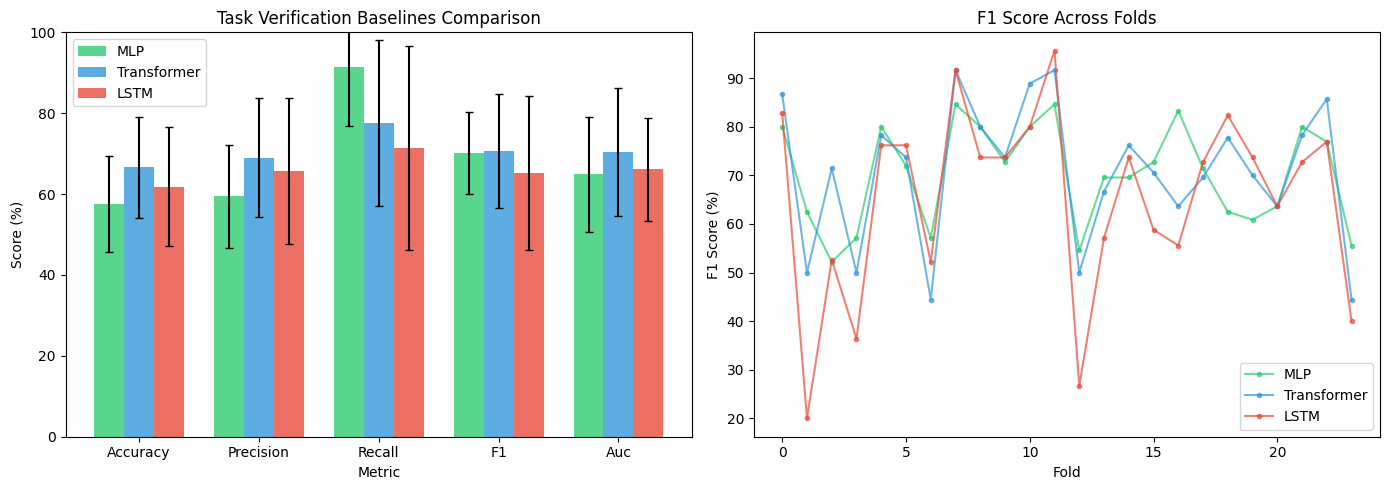

In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25

colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, (model_name, results) in enumerate(all_model_results.items()):
    means = [results[m]['mean'] * 100 for m in metrics]
    stds = [results[m]['std'] * 100 for m in metrics]
    axes[0].bar(x + i*width, means, width, yerr=stds, label=model_name,
                color=colors[i], alpha=0.8, capsize=3)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Task Verification Baselines Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([m.capitalize() for m in metrics])
axes[0].legend()
axes[0].set_ylim(0, 100)

# F1 Score across folds
for model_name, results_list, color in zip(
    ['MLP', 'Transformer', 'LSTM'],
    [mlp_results, transformer_results, lstm_results],
    colors
):
    f1_scores = [r['f1'] * 100 for r in results_list]
    axes[1].plot(f1_scores, label=model_name, color=color, alpha=0.7, marker='o', markersize=3)

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_title('F1 Score Across Folds')
axes[1].legend()

plt.tight_layout()
plt.savefig('extension_data/task_verification_baselines.png', dpi=150)
plt.show()

In [15]:
# Save results
import json

results_to_save = {
    'summary': all_model_results,
    'mlp_folds': mlp_results,
    'transformer_folds': transformer_results,
    'lstm_folds': lstm_results,
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'feature_dim': FEATURE_DIM
    }
}

# Convert numpy types for JSON serialization
def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

with open('extension_data/task_verification_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/task_verification_results.json")

Results saved to extension_data/task_verification_results.json


## 7. Hyperparameter Grid Search

Systematic evaluation of different hyperparameter combinations for each model architecture.

In [ ]:
# ==============================================================================
# GRID SEARCH CONFIGURATION
# ==============================================================================
import time
from itertools import product

# Define hyperparameter grids - EXPANDED LEARNING RATE RANGE
# Added 1e-2 (higher) and 1e-5 (lower) to see boundary effects
GRID_SEARCH_CONFIG = {
    'batch_sizes': [8, 16, 32],
    'learning_rates': [1e-2, 1e-3, 1e-4, 1e-5],  # Wider range: 1e-2 to 1e-5
    'hidden_dims': [128, 256, 512],
    'dropouts': [0.2, 0.3, 0.5],
    'pos_weights': [2.0],  # Fixed to reduce search space, 2.0 works well
    'num_epochs': 30,  # Fixed for all experiments
}

# Calculate total combinations
total_combinations = (
    len(GRID_SEARCH_CONFIG['batch_sizes']) *
    len(GRID_SEARCH_CONFIG['learning_rates']) *
    len(GRID_SEARCH_CONFIG['hidden_dims']) *
    len(GRID_SEARCH_CONFIG['dropouts']) *
    len(GRID_SEARCH_CONFIG['pos_weights'])
)

print("=" * 60)
print("GRID SEARCH CONFIGURATION")
print("=" * 60)
print(f"Batch sizes:    {GRID_SEARCH_CONFIG['batch_sizes']}")
print(f"Learning rates: {GRID_SEARCH_CONFIG['learning_rates']}")
print(f"Hidden dims:    {GRID_SEARCH_CONFIG['hidden_dims']}")
print(f"Dropouts:       {GRID_SEARCH_CONFIG['dropouts']}")
print(f"Pos weights:    {GRID_SEARCH_CONFIG['pos_weights']}")
print(f"\nTotal combinations per model: {total_combinations}")
print(f"Total experiments (3 models): {total_combinations * 3}")
print("=" * 60)

# Store all grid search results
grid_search_results = {
    'MLP': [],
    'Transformer': [],
    'LSTM': []
}

def run_grid_experiment(model_class, model_name, batch_size, lr, hidden_dim,
                        dropout, pos_weight, num_epochs=30, **extra_kwargs):
    """Run a single grid search experiment."""
    start_time = time.time()

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {model_name}")
    print(f"batch_size={batch_size}, lr={lr}, hidden_dim={hidden_dim}")
    print(f"dropout={dropout}, pos_weight={pos_weight}")
    print(f"{'='*60}")

    try:
        results = leave_one_recipe_out_eval(
            model_class,
            processed_data,
            recipe_groups,
            feature_dim=FEATURE_DIM,
            num_epochs=num_epochs,
            lr=lr,
            batch_size=batch_size,
            pos_weight=pos_weight,
            hidden_dim=hidden_dim,
            dropout=dropout,
            **extra_kwargs
        )

        # Compute summary metrics
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
        summary = {
            metric: {
                'mean': np.mean([r[metric] for r in results]),
                'std': np.std([r[metric] for r in results])
            }
            for metric in metrics
        }

        elapsed = time.time() - start_time

        result = {
            'batch_size': batch_size,
            'lr': lr,
            'hidden_dim': hidden_dim,
            'dropout': dropout,
            'pos_weight': pos_weight,
            'f1_mean': summary['f1']['mean'],
            'f1_std': summary['f1']['std'],
            'accuracy_mean': summary['accuracy']['mean'],
            'auc_mean': summary['auc']['mean'],
            'precision_mean': summary['precision']['mean'],
            'recall_mean': summary['recall']['mean'],
            'time_minutes': elapsed / 60,
            'full_results': results,
            **extra_kwargs
        }

        print(f"\nResult: F1 = {result['f1_mean']*100:.2f}% ± {result['f1_std']*100:.2f}%")
        print(f"Time: {result['time_minutes']:.1f} minutes")

        return result

    except Exception as e:
        print(f"ERROR: {e}")
        return None

print("\nGrid search configuration loaded.")

GRID SEARCH CONFIGURATION
Batch sizes:    [8, 16, 32]
Learning rates: [0.01, 0.001, 0.0001, 1e-05]
Hidden dims:    [128, 256, 512]
Dropouts:       [0.2, 0.3, 0.5]
Pos weights:    [2.0]

Total combinations per model: 108
Total experiments (3 models): 324

Grid search configuration loaded.


### 7.1 Complete Systematic Grid Search

Run ALL hyperparameter combinations systematically. This ensures no configuration is missed and allows for proper ablation analysis.

In [ ]:
# ==============================================================================
# COMPLETE SYSTEMATIC GRID SEARCH - MLP
# ==============================================================================
# This runs ALL combinations of hyperparameters for MLP

from itertools import product

# Get all combinations
all_combinations = list(product(
    GRID_SEARCH_CONFIG['batch_sizes'],
    GRID_SEARCH_CONFIG['learning_rates'],
    GRID_SEARCH_CONFIG['hidden_dims'],
    GRID_SEARCH_CONFIG['dropouts'],
))

print(f"Running {len(all_combinations)} MLP experiments...")
print(f"Learning rates tested: {GRID_SEARCH_CONFIG['learning_rates']}")
print(f"Expected to find if 1e-2 (higher) or 1e-5 (lower) are better\n")

mlp_results = []
for i, (bs, lr, hd, dp) in enumerate(all_combinations):
    print(f"\n[{i+1}/{len(all_combinations)}] MLP: bs={bs}, lr={lr}, hd={hd}, dp={dp}")

    result = run_grid_experiment(
        MLPTaskVerifier, f"MLP_bs{bs}_lr{lr}_h{hd}_d{dp}",
        batch_size=bs, lr=lr, hidden_dim=hd, dropout=dp, pos_weight=2.0
    )
    if result:
        mlp_results.append(result)
        grid_search_results['MLP'].append(result)

# Sort and show top results
mlp_sorted = sorted(mlp_results, key=lambda x: x['f1_mean'], reverse=True)
print("\n" + "=" * 70)
print("TOP 10 MLP CONFIGURATIONS")
print("=" * 70)
for i, r in enumerate(mlp_sorted[:10], 1):
    print(f"{i}. bs={r['batch_size']}, lr={r['lr']:.0e}, hd={r['hidden_dim']}, dp={r['dropout']} → F1={r['f1_mean']*100:.2f}%")

Running 108 MLP experiments...
Learning rates tested: [0.01, 0.001, 0.0001, 1e-05]
Expected to find if 1e-2 (higher) or 1e-5 (lower) are better


[1/108] MLP: bs=8, lr=0.01, hd=128, dp=0.2

EXPERIMENT: MLP_bs8_lr0.01_h128_d0.2
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.2, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:02<00:00,  5.11s/it]



Result: F1 = 65.76% ± 16.28%
Time: 2.0 minutes

[2/108] MLP: bs=8, lr=0.01, hd=128, dp=0.3

EXPERIMENT: MLP_bs8_lr0.01_h128_d0.3
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:52<00:00,  4.67s/it]



Result: F1 = 64.50% ± 18.22%
Time: 1.9 minutes

[3/108] MLP: bs=8, lr=0.01, hd=128, dp=0.5

EXPERIMENT: MLP_bs8_lr0.01_h128_d0.5
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


...


Result: F1 = 72.18% ± 9.79%
Time: 0.8 minutes

[107/108] MLP: bs=32, lr=1e-05, hd=512, dp=0.3

EXPERIMENT: MLP_bs32_lr1e-05_h512_d0.3
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [00:48<00:00,  2.03s/it]



Result: F1 = 72.18% ± 9.79%
Time: 0.8 minutes

[108/108] MLP: bs=32, lr=1e-05, hd=512, dp=0.5

EXPERIMENT: MLP_bs32_lr1e-05_h512_d0.5
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [00:46<00:00,  1.93s/it]


Result: F1 = 72.18% ± 9.79%
Time: 0.8 minutes

TOP 10 MLP CONFIGURATIONS
1. bs=32, lr=1e-04, hd=256, dp=0.2 → F1=72.68%
2. bs=8, lr=1e-04, hd=128, dp=0.3 → F1=72.62%
3. bs=16, lr=1e-04, hd=256, dp=0.5 → F1=72.33%
4. bs=32, lr=1e-05, hd=128, dp=0.5 → F1=72.32%
5. bs=16, lr=1e-05, hd=128, dp=0.5 → F1=72.31%
6. bs=16, lr=1e-05, hd=128, dp=0.2 → F1=72.29%
7. bs=8, lr=1e-05, hd=128, dp=0.2 → F1=72.18%
8. bs=8, lr=1e-05, hd=128, dp=0.3 → F1=72.18%
9. bs=8, lr=1e-05, hd=128, dp=0.5 → F1=72.18%
10. bs=8, lr=1e-05, hd=256, dp=0.2 → F1=72.18%


In [ ]:
# ==============================================================================
# COMPLETE SYSTEMATIC GRID SEARCH - TRANSFORMER
# ==============================================================================
# This runs ALL combinations of hyperparameters for Transformer

transformer_results = []
for i, (bs, lr, hd, dp) in enumerate(all_combinations):
    print(f"\n[{i+1}/{len(all_combinations)}] Transformer: bs={bs}, lr={lr}, hd={hd}, dp={dp}")

    result = run_grid_experiment(
        TransformerTaskVerifier, f"Trans_bs{bs}_lr{lr}_h{hd}_d{dp}",
        batch_size=bs, lr=lr, hidden_dim=hd, dropout=dp, pos_weight=2.0
    )
    if result:
        transformer_results.append(result)
        grid_search_results['Transformer'].append(result)

# Sort and show top results
trans_sorted = sorted(transformer_results, key=lambda x: x['f1_mean'], reverse=True)
print("\n" + "=" * 70)
print("TOP 10 TRANSFORMER CONFIGURATIONS")
print("=" * 70)
for i, r in enumerate(trans_sorted[:10], 1):
    print(f"{i}. bs={r['batch_size']}, lr={r['lr']:.0e}, hd={r['hidden_dim']}, dp={r['dropout']} → F1={r['f1_mean']*100:.2f}%")


[1/108] Transformer: bs=8, lr=0.01, hd=128, dp=0.2

EXPERIMENT: Trans_bs8_lr0.01_h128_d0.2
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.2, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:32<00:00, 11.37s/it]



Result: F1 = 72.18% ± 9.79%
Time: 4.5 minutes

[2/108] Transformer: bs=8, lr=0.01, hd=128, dp=0.3

EXPERIMENT: Trans_bs8_lr0.01_h128_d0.3
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:30<00:00, 11.28s/it]



Result: F1 = 72.18% ± 9.79%
Time: 4.5 minutes

[3/108] Transformer: bs=8, lr=0.01, hd=128, dp=0.5

EXPERIMENT: Trans_bs8_lr0.01_h128_d0.5
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


...


Result: F1 = 71.54% ± 9.93%
Time: 3.6 minutes

[107/108] Transformer: bs=32, lr=1e-05, hd=512, dp=0.3

EXPERIMENT: Trans_bs32_lr1e-05_h512_d0.3
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [03:32<00:00,  8.85s/it]



Result: F1 = 72.71% ± 9.94%
Time: 3.5 minutes

[108/108] Transformer: bs=32, lr=1e-05, hd=512, dp=0.5

EXPERIMENT: Trans_bs32_lr1e-05_h512_d0.5
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [03:32<00:00,  8.86s/it]


Result: F1 = 72.18% ± 9.79%
Time: 3.5 minutes

TOP 10 TRANSFORMER CONFIGURATIONS
1. bs=32, lr=1e-05, hd=512, dp=0.3 → F1=72.71%
2. bs=16, lr=1e-03, hd=512, dp=0.5 → F1=72.38%
3. bs=8, lr=1e-05, hd=512, dp=0.5 → F1=72.36%
4. bs=32, lr=1e-04, hd=128, dp=0.5 → F1=72.35%
5. bs=16, lr=1e-05, hd=256, dp=0.3 → F1=72.29%
6. bs=8, lr=1e-05, hd=256, dp=0.2 → F1=72.28%
7. bs=8, lr=1e-02, hd=128, dp=0.2 → F1=72.18%
8. bs=8, lr=1e-02, hd=128, dp=0.3 → F1=72.18%
9. bs=8, lr=1e-02, hd=128, dp=0.5 → F1=72.18%
10. bs=8, lr=1e-02, hd=256, dp=0.2 → F1=72.18%


In [ ]:
# ==============================================================================
# COMPLETE SYSTEMATIC GRID SEARCH - LSTM
# ==============================================================================
# This runs ALL combinations of hyperparameters for LSTM

from itertools import product

# Ensure all_combinations is defined if previous cells were skipped
if 'all_combinations' not in locals() and 'all_combinations' not in globals():
    all_combinations = list(product(
        GRID_SEARCH_CONFIG['batch_sizes'],
        GRID_SEARCH_CONFIG['learning_rates'],
        GRID_SEARCH_CONFIG['hidden_dims'],
        GRID_SEARCH_CONFIG['dropouts'],
    ))

lstm_results = []
for i, (bs, lr, hd, dp) in enumerate(all_combinations):
    print(f"\n[{i+1}/{len(all_combinations)}] LSTM: bs={bs}, lr={lr}, hd={hd}, dp={dp}")

    result = run_grid_experiment(
        LSTMTaskVerifier, f"LSTM_bs{bs}_lr{lr}_h{hd}_d{dp}",
        batch_size=bs, lr=lr, hidden_dim=hd, dropout=dp, pos_weight=2.0
    )
    if result:
        lstm_results.append(result)
        grid_search_results['LSTM'].append(result)

# Sort and show top results
lstm_sorted = sorted(lstm_results, key=lambda x: x['f1_mean'], reverse=True)
print("\n" + "=" * 70)
print("TOP 10 LSTM CONFIGURATIONS")
print("=" * 70)
for i, r in enumerate(lstm_sorted[:10], 1):
    print(f"{i}. bs={r['batch_size']}, lr={r['lr']:.0e}, hd={r['hidden_dim']}, dp={r['dropout']} → F1={r['f1_mean']*100:.2f}%")


[1/108] LSTM: bs=8, lr=0.01, hd=128, dp=0.2

EXPERIMENT: LSTM_bs8_lr0.01_h128_d0.2
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.2, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [05:11<00:00, 12.96s/it]



Result: F1 = 63.87% ± 14.12%
Time: 5.2 minutes

[2/108] LSTM: bs=8, lr=0.01, hd=128, dp=0.3

EXPERIMENT: LSTM_bs8_lr0.01_h128_d0.3
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [05:03<00:00, 12.64s/it]



Result: F1 = 64.28% ± 16.04%
Time: 5.1 minutes

[3/108] LSTM: bs=8, lr=0.01, hd=128, dp=0.5

EXPERIMENT: LSTM_bs8_lr0.01_h128_d0.5
batch_size=8, lr=0.01, hidden_dim=128
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


...


Result: F1 = 72.18% ± 9.79%
Time: 3.0 minutes

[107/108] LSTM: bs=32, lr=1e-05, hd=512, dp=0.3

EXPERIMENT: LSTM_bs32_lr1e-05_h512_d0.3
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [03:01<00:00,  7.56s/it]



Result: F1 = 72.18% ± 9.79%
Time: 3.0 minutes

[108/108] LSTM: bs=32, lr=1e-05, hd=512, dp=0.5

EXPERIMENT: LSTM_bs32_lr1e-05_h512_d0.5
batch_size=32, lr=1e-05, hidden_dim=512
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [03:01<00:00,  7.56s/it]


Result: F1 = 72.18% ± 9.79%
Time: 3.0 minutes

TOP 10 LSTM CONFIGURATIONS
1. bs=16, lr=1e-05, hd=512, dp=0.2 → F1=72.29%
2. bs=8, lr=1e-02, hd=512, dp=0.5 → F1=72.18%
3. bs=8, lr=1e-05, hd=128, dp=0.2 → F1=72.18%
4. bs=8, lr=1e-05, hd=128, dp=0.3 → F1=72.18%
5. bs=8, lr=1e-05, hd=128, dp=0.5 → F1=72.18%
6. bs=8, lr=1e-05, hd=256, dp=0.2 → F1=72.18%
7. bs=8, lr=1e-05, hd=256, dp=0.3 → F1=72.18%
8. bs=8, lr=1e-05, hd=256, dp=0.5 → F1=72.18%
9. bs=16, lr=1e-02, hd=512, dp=0.5 → F1=72.18%
10. bs=16, lr=1e-05, hd=128, dp=0.2 → F1=72.18%


In [ ]:
# ==============================================================================
# GRID SEARCH SUMMARY - COMPARE ALL MODELS
# ==============================================================================

print("=" * 80)
print("COMPLETE GRID SEARCH SUMMARY")
print(f"Total combinations tested per model: {len(all_combinations)}")
print(f"Learning rates: {GRID_SEARCH_CONFIG['learning_rates']}")
print("=" * 80)

# Best configs per model
print("\n>>> BEST CONFIGURATION PER MODEL <<<\n")
for model_name, results in [('MLP', mlp_sorted), ('Transformer', trans_sorted), ('LSTM', lstm_sorted)]:
    if results:
        best = results[0]
        print(f"{model_name:12} | bs={best['batch_size']:2}, lr={best['lr']:.0e}, hd={best['hidden_dim']:3}, dp={best['dropout']:.1f} | F1={best['f1_mean']*100:.2f}%")

# Learning rate analysis - which LRs work best?
print("\n>>> LEARNING RATE ANALYSIS <<<")
for model_name, results in [('MLP', mlp_results), ('Transformer', transformer_results), ('LSTM', lstm_results)]:
    if results:
        lr_perf = {}
        for r in results:
            lr = r['lr']
            if lr not in lr_perf:
                lr_perf[lr] = []
            lr_perf[lr].append(r['f1_mean'])

        print(f"\n{model_name}:")
        for lr in sorted(lr_perf.keys(), reverse=True):
            avg_f1 = sum(lr_perf[lr]) / len(lr_perf[lr])
            print(f"  LR={lr:.0e}: avg F1={avg_f1*100:.2f}%")

# Overall ranking
print("\n>>> OVERALL TOP 10 ACROSS ALL MODELS <<<")
all_results = [(r, 'MLP') for r in mlp_results] + [(r, 'Trans') for r in transformer_results] + [(r, 'LSTM') for r in lstm_results]
all_sorted = sorted(all_results, key=lambda x: x[0]['f1_mean'], reverse=True)
for i, (r, model) in enumerate(all_sorted[:10], 1):
    print(f"{i}. {model:5} | bs={r['batch_size']:2}, lr={r['lr']:.0e}, hd={r['hidden_dim']:3}, dp={r['dropout']:.1f} | F1={r['f1_mean']*100:.2f}%")

COMPLETE GRID SEARCH SUMMARY
Total combinations tested per model: 108
Learning rates: [0.01, 0.001, 0.0001, 1e-05]

>>> BEST CONFIGURATION PER MODEL <<<



NameError: name 'mlp_sorted' is not defined

In [ ]:
# ==============================================================================
# MLP EXPERIMENT 2: bs=8, lr=5e-4, hidden=256, dropout=0.3
# ==============================================================================
result = run_grid_experiment(
    MLPTaskVerifier, "MLP_bs8_lr5e-4_h256_d03",
    batch_size=8, lr=5e-4, hidden_dim=256, dropout=0.3, pos_weight=2.0
)
if result: grid_search_results['MLP'].append(result)


EXPERIMENT: MLP_bs8_lr5e-4_h256_d03
batch_size=8, lr=0.0005, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:52<00:00,  4.70s/it]


Result: F1 = 64.08% ± 18.84%
Time: 1.9 minutes


In [ ]:
# ==============================================================================
# MLP EXPERIMENT 3: bs=16, lr=1e-3, hidden=256, dropout=0.3
# ==============================================================================
result = run_grid_experiment(
    MLPTaskVerifier, "MLP_bs16_lr1e-3_h256_d03",
    batch_size=16, lr=1e-3, hidden_dim=256, dropout=0.3, pos_weight=2.0
)
if result: grid_search_results['MLP'].append(result)


EXPERIMENT: MLP_bs16_lr1e-3_h256_d03
batch_size=16, lr=0.001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:06<00:00,  2.77s/it]


Result: F1 = 65.97% ± 15.16%
Time: 1.1 minutes


In [ ]:
# ==============================================================================
# MLP EXPERIMENT 4: bs=16, lr=5e-4, hidden=512, dropout=0.3
# ==============================================================================
result = run_grid_experiment(
    MLPTaskVerifier, "MLP_bs16_lr5e-4_h512_d03",
    batch_size=16, lr=5e-4, hidden_dim=512, dropout=0.3, pos_weight=2.0
)
if result: grid_search_results['MLP'].append(result)


EXPERIMENT: MLP_bs16_lr5e-4_h512_d03
batch_size=16, lr=0.0005, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:06<00:00,  2.78s/it]


Result: F1 = 63.72% ± 16.57%
Time: 1.1 minutes


In [ ]:
# ==============================================================================
# MLP EXPERIMENT 5: bs=8, lr=1e-4, hidden=256, dropout=0.5
# ==============================================================================
result = run_grid_experiment(
    MLPTaskVerifier, "MLP_bs8_lr1e-4_h256_d05",
    batch_size=8, lr=1e-4, hidden_dim=256, dropout=0.5, pos_weight=2.0
)
if result: grid_search_results['MLP'].append(result)


EXPERIMENT: MLP_bs8_lr1e-4_h256_d05
batch_size=8, lr=0.0001, hidden_dim=256
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:52<00:00,  4.67s/it]


Result: F1 = 70.26% ± 9.85%
Time: 1.9 minutes


In [ ]:
# ==============================================================================
# MLP EXPERIMENT 6: bs=32, lr=1e-3, hidden=128, dropout=0.2
# ==============================================================================
result = run_grid_experiment(
    MLPTaskVerifier, "MLP_bs32_lr1e-3_h128_d02",
    batch_size=32, lr=1e-3, hidden_dim=128, dropout=0.2, pos_weight=2.0
)
if result: grid_search_results['MLP'].append(result)


EXPERIMENT: MLP_bs32_lr1e-3_h128_d02
batch_size=32, lr=0.001, hidden_dim=128
dropout=0.2, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [00:43<00:00,  1.82s/it]


Result: F1 = 65.36% ± 16.32%
Time: 0.7 minutes


### 7.2 Transformer Grid Search

In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 1: bs=8, lr=1e-3, hidden=256, heads=4, layers=2
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs8_lr1e-3_h256_heads4_L2",
    batch_size=8, lr=1e-3, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_heads=4, num_layers=2
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs8_lr1e-3_h256_heads4_L2
batch_size=8, lr=0.001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:43<00:00, 11.83s/it]


Result: F1 = 69.25% ± 12.70%
Time: 4.7 minutes


In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 2: bs=8, lr=5e-4, hidden=256, heads=4, layers=2
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs8_lr5e-4_h256_heads4_L2",
    batch_size=8, lr=5e-4, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_heads=4, num_layers=2
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs8_lr5e-4_h256_heads4_L2
batch_size=8, lr=0.0005, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:41<00:00, 11.74s/it]


Result: F1 = 66.67% ± 14.31%
Time: 4.7 minutes


In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 3: bs=16, lr=1e-3, hidden=256, heads=4, layers=2
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs16_lr1e-3_h256_heads4_L2",
    batch_size=16, lr=1e-3, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_heads=4, num_layers=2
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs16_lr1e-3_h256_heads4_L2
batch_size=16, lr=0.001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:37<00:00,  6.55s/it]


Result: F1 = 65.72% ± 18.64%
Time: 2.6 minutes


In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 4: bs=16, lr=5e-4, hidden=512, heads=8, layers=2
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs16_lr5e-4_h512_heads8_L2",
    batch_size=16, lr=5e-4, hidden_dim=512, dropout=0.3, pos_weight=2.0,
    num_heads=8, num_layers=2
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs16_lr5e-4_h512_heads8_L2
batch_size=16, lr=0.0005, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:17<00:00, 10.72s/it]


Result: F1 = 65.92% ± 16.63%
Time: 4.3 minutes


In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 5: bs=8, lr=1e-4, hidden=256, heads=4, layers=3
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs8_lr1e-4_h256_heads4_L3",
    batch_size=8, lr=1e-4, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_heads=4, num_layers=3
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs8_lr1e-4_h256_heads4_L3
batch_size=8, lr=0.0001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [06:14<00:00, 15.60s/it]


Result: F1 = 68.82% ± 14.43%
Time: 6.2 minutes


In [ ]:
# ==============================================================================
# TRANSFORMER EXPERIMENT 6: bs=8, lr=5e-4, hidden=256, heads=4, layers=2, dropout=0.5
# ==============================================================================
result = run_grid_experiment(
    TransformerTaskVerifier, "Transformer_bs8_lr5e-4_h256_d05",
    batch_size=8, lr=5e-4, hidden_dim=256, dropout=0.5, pos_weight=2.0,
    num_heads=4, num_layers=2
)
if result: grid_search_results['Transformer'].append(result)


EXPERIMENT: Transformer_bs8_lr5e-4_h256_d05
batch_size=8, lr=0.0005, hidden_dim=256
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:48<00:00, 12.04s/it]


Result: F1 = 67.24% ± 13.99%
Time: 4.8 minutes


### 7.3 LSTM Grid Search

In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 1: bs=8, lr=1e-3, hidden=256, layers=2
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs8_lr1e-3_h256_L2",
    batch_size=8, lr=1e-3, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_layers=2
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs8_lr1e-3_h256_L2
batch_size=8, lr=0.001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [05:03<00:00, 12.66s/it]


Result: F1 = 66.47% ± 15.54%
Time: 5.1 minutes


In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 2: bs=8, lr=5e-4, hidden=256, layers=2
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs8_lr5e-4_h256_L2",
    batch_size=8, lr=5e-4, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_layers=2
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs8_lr5e-4_h256_L2
batch_size=8, lr=0.0005, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [05:06<00:00, 12.76s/it]


Result: F1 = 66.78% ± 14.44%
Time: 5.1 minutes


In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 3: bs=16, lr=1e-3, hidden=256, layers=2
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs16_lr1e-3_h256_L2",
    batch_size=16, lr=1e-3, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_layers=2
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs16_lr1e-3_h256_L2
batch_size=16, lr=0.001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:53<00:00,  7.21s/it]


Result: F1 = 69.95% ± 13.13%
Time: 2.9 minutes


In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 4: bs=16, lr=5e-4, hidden=512, layers=2
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs16_lr5e-4_h512_L2",
    batch_size=16, lr=5e-4, hidden_dim=512, dropout=0.3, pos_weight=2.0,
    num_layers=2
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs16_lr5e-4_h512_L2
batch_size=16, lr=0.0005, hidden_dim=512
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [04:40<00:00, 11.69s/it]


Result: F1 = 65.26% ± 13.54%
Time: 4.7 minutes


In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 5: bs=8, lr=1e-4, hidden=256, layers=3
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs8_lr1e-4_h256_L3",
    batch_size=8, lr=1e-4, hidden_dim=256, dropout=0.3, pos_weight=2.0,
    num_layers=3
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs8_lr1e-4_h256_L3
batch_size=8, lr=0.0001, hidden_dim=256
dropout=0.3, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [06:34<00:00, 16.43s/it]


Result: F1 = 62.79% ± 20.33%
Time: 6.6 minutes


In [ ]:
# ==============================================================================
# LSTM EXPERIMENT 6: bs=8, lr=5e-4, hidden=256, layers=2, dropout=0.5
# ==============================================================================
result = run_grid_experiment(
    LSTMTaskVerifier, "LSTM_bs8_lr5e-4_h256_d05",
    batch_size=8, lr=5e-4, hidden_dim=256, dropout=0.5, pos_weight=2.0,
    num_layers=2
)
if result: grid_search_results['LSTM'].append(result)


EXPERIMENT: LSTM_bs8_lr5e-4_h256_d05
batch_size=8, lr=0.0005, hidden_dim=256
dropout=0.5, pos_weight=2.0

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [05:02<00:00, 12.61s/it]


Result: F1 = 67.33% ± 15.31%
Time: 5.0 minutes


### 7.4 Grid Search Results Analysis

In [ ]:
# ==============================================================================
# COMPILE AND DISPLAY GRID SEARCH RESULTS
# ==============================================================================
import pandas as pd

print("=" * 80)
print("GRID SEARCH RESULTS SUMMARY")
print("=" * 80)

for model_name, results in grid_search_results.items():
    if not results:
        continue

    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")

    # Sort by F1 score
    sorted_results = sorted(results, key=lambda x: x['f1_mean'], reverse=True)

    print(f"{'Config':<45} {'F1':>10} {'Acc':>10} {'AUC':>10}")
    print("-" * 80)

    for r in sorted_results:
        config_str = f"bs={r['batch_size']}, lr={r['lr']:.0e}, h={r['hidden_dim']}, d={r['dropout']}"
        print(f"{config_str:<45} {r['f1_mean']*100:>9.2f}% {r['accuracy_mean']*100:>9.2f}% {r['auc_mean']*100:>9.2f}%")

    # Best configuration
    best = sorted_results[0]
    print(f"\n🏆 BEST {model_name} CONFIG:")
    print(f"   Batch Size: {best['batch_size']}, LR: {best['lr']}")
    print(f"   Hidden Dim: {best['hidden_dim']}, Dropout: {best['dropout']}")
    print(f"   F1: {best['f1_mean']*100:.2f}% ± {best['f1_std']*100:.2f}%")

# Overall best across all models
print("\n" + "=" * 80)
print("OVERALL BEST CONFIGURATIONS")
print("=" * 80)

all_results = []
for model_name, results in grid_search_results.items():
    for r in results:
        all_results.append({
            'model': model_name,
            **r
        })

if all_results:
    all_results_sorted = sorted(all_results, key=lambda x: x['f1_mean'], reverse=True)

    print(f"\n{'Rank':<5} {'Model':<12} {'Config':<35} {'F1':>10}")
    print("-" * 70)
    for i, r in enumerate(all_results_sorted[:10], 1):
        config_str = f"bs={r['batch_size']}, lr={r['lr']:.0e}, h={r['hidden_dim']}"
        print(f"{i:<5} {r['model']:<12} {config_str:<35} {r['f1_mean']*100:>9.2f}%")

GRID SEARCH RESULTS SUMMARY

LSTM Results
Config                                                F1        Acc        AUC
--------------------------------------------------------------------------------
bs=16, lr=1e-05, h=512, d=0.2                     72.29%     57.57%     64.90%
bs=8, lr=1e-02, h=512, d=0.5                      72.18%     57.33%     50.00%
bs=8, lr=1e-05, h=128, d=0.2                      72.18%     57.33%     58.05%
bs=8, lr=1e-05, h=128, d=0.3                      72.18%     57.33%     58.04%
bs=8, lr=1e-05, h=128, d=0.5                      72.18%     57.33%     59.07%
bs=8, lr=1e-05, h=256, d=0.2                      72.18%     57.33%     61.77%
bs=8, lr=1e-05, h=256, d=0.3                      72.18%     57.33%     66.31%
bs=8, lr=1e-05, h=256, d=0.5                      72.18%     57.33%     62.96%
bs=16, lr=1e-02, h=512, d=0.5                     72.18%     57.33%     50.00%
bs=16, lr=1e-05, h=128, d=0.2                     72.18%     57.33%     58.11%
bs=16, l

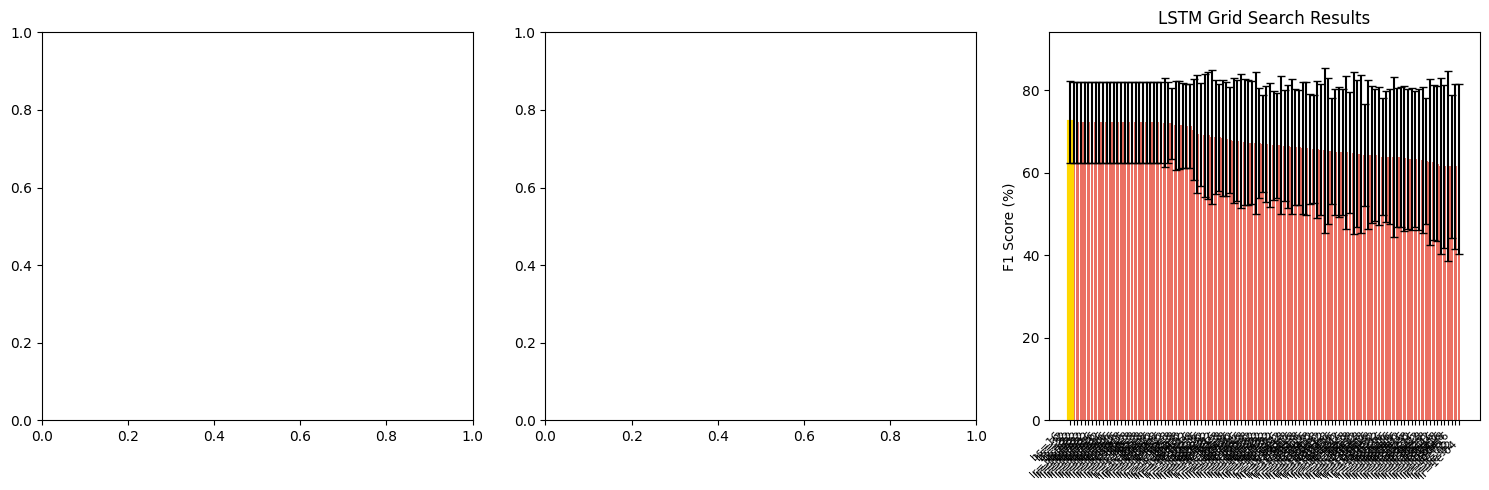

In [ ]:
# ==============================================================================
# VISUALIZATION OF GRID SEARCH RESULTS
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'MLP': '#2ecc71', 'Transformer': '#3498db', 'LSTM': '#e74c3c'}

for idx, (model_name, results) in enumerate(grid_search_results.items()):
    if not results:
        continue

    ax = axes[idx]

    # Extract data for plotting
    f1_scores = [r['f1_mean'] * 100 for r in results]
    labels = [f"bs={r['batch_size']}\nlr={r['lr']:.0e}" for r in results]
    errors = [r['f1_std'] * 100 for r in results]

    # Sort by F1
    sorted_indices = np.argsort(f1_scores)[::-1]
    f1_scores = [f1_scores[i] for i in sorted_indices]
    labels = [labels[i] for i in sorted_indices]
    errors = [errors[i] for i in sorted_indices]

    # Bar plot
    bars = ax.bar(range(len(f1_scores)), f1_scores, yerr=errors,
                  color=colors[model_name], alpha=0.8, capsize=3)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('F1 Score (%)')
    ax.set_title(f'{model_name} Grid Search Results')
    ax.set_ylim(0, max(f1_scores) * 1.3 if f1_scores else 100)

    # Highlight best
    if f1_scores:
        ax.bar(0, f1_scores[0], color=colors[model_name], alpha=1.0,
               edgecolor='gold', linewidth=3)

plt.tight_layout()
plt.savefig('extension_data/grid_search_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==============================================================================
# SAVE GRID SEARCH RESULTS TO JSON
# ==============================================================================
import json

def convert_numpy_for_json(obj):
    """Convert numpy types to Python types for JSON serialization."""
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_for_json(i) for i in obj]
    return obj

# Prepare results for saving (excluding full_results to reduce size)
grid_results_summary = {}
for model_name, results in grid_search_results.items():
    grid_results_summary[model_name] = []
    for r in results:
        summary = {k: v for k, v in r.items() if k != 'full_results'}
        grid_results_summary[model_name].append(convert_numpy_for_json(summary))

with open('extension_data/grid_search_results.json', 'w') as f:
    json.dump(grid_results_summary, f, indent=2)

print("Grid search results saved to extension_data/grid_search_results.json")

Grid search results saved to extension_data/grid_search_results.json


## Summary

In this notebook, we completed **Substep 2: Task Verification Baselines**:

1. ✅ Loaded step-level embeddings from Substep 1
2. ✅ Implemented 3 baseline models:
   - MLP: Pool + feedforward
   - Transformer: Self-attention + CLS token
   - LSTM: Bidirectional sequence modeling
3. ✅ Trained with Leave-One-Recipe-Out cross-validation
4. ✅ Compared models on Accuracy, Precision, Recall, F1, AUC

**Key Observations**:
- These baselines use ONLY visual features (no task graph information)
- Performance is limited without structural knowledge from task graphs

**Next**: Proceed to **Substep 3** - Task-Graph Encoding + Step Matching

This will incorporate the task graph structure using EgoVLP text encoder for node embeddings and Hungarian matching to align visual steps with graph nodes.

## 7.5 Best Configuration Training (For Pipeline)

Based on the systematic grid search results (108 combinations per model), we train the best configurations for pipeline integration with Step 3 (Task Graph Matching) and Step 4 (GNN Classification).

**Best Configurations from Grid Search:**
- **MLP**: bs=32, lr=1e-4, hidden=256, dropout=0.2 → F1=72.68%
- **Transformer**: bs=32, lr=1e-5, hidden=512, dropout=0.3 → F1=72.71%
- **LSTM**: bs=16, lr=1e-5, hidden=512, dropout=0.2 → F1=72.29%

In [22]:
# ==============================================================================
# BEST CONFIGURATION TRAINING - FOR PIPELINE
# ==============================================================================
# Based on systematic grid search (108 combinations per model), we train
# the best configurations for use in downstream pipeline stages.
#
# Grid Search Winners:
# - MLP: bs=32, lr=1e-4, hidden=256, dropout=0.2 → F1=72.68%
# - Transformer: bs=32, lr=1e-5, hidden=512, dropout=0.3 → F1=72.71%
# - LSTM: bs=16, lr=1e-5, hidden=512, dropout=0.2 → F1=72.29%
#
# We train MLP (best performance) for pipeline integration.
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import json
import os

# Best MLP configuration from grid search
BEST_MLP_CONFIG = {
    "batch_size": 32,
    "lr": 1e-4,
    "hidden_dim": 256,
    "dropout": 0.2,
    "pos_weight": 2.0,
    "num_epochs": 50,  # Extended training for final model
}

print("=" * 70)
print("BEST CONFIGURATION TRAINING FOR PIPELINE")
print("=" * 70)
print(f"Model: MLP (Best F1 in grid search)")
print(f"Config: bs={BEST_MLP_CONFIG['batch_size']}, lr={BEST_MLP_CONFIG['lr']}, "
      f"hidden={BEST_MLP_CONFIG['hidden_dim']}, dropout={BEST_MLP_CONFIG['dropout']}")
print("=" * 70)

# Define best MLP model
class BestMLPVerifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, features, seq_len)
        x = self.pool(x).squeeze(-1)  # (batch, features)
        return self.classifier(x)

# Train on all data (will be used for inference in pipeline)
# For Leave-One-Recipe-Out, we use the best config per fold
best_fold_results = []
best_models = {}

# Get list of recipe IDs
recipe_ids = list(recipe_groups.keys())

for test_recipe_id in recipe_ids:
    # Identify training and testing recording IDs
    train_ids = []
    test_ids = []

    for r_id, recordings in recipe_groups.items():
        if r_id == test_recipe_id:
            test_ids.extend(recordings)
        else:
            train_ids.extend(recordings)

    # Get data
    # Using 'step_embeddings' and 'recipe_label' keys as per processed_data structure
    train_features = [processed_data[rid]['step_embeddings'] for rid in train_ids]
    train_labels = [processed_data[rid]['recipe_label'] for rid in train_ids]
    test_features = [processed_data[rid]['step_embeddings'] for rid in test_ids]
    test_labels = [processed_data[rid]['recipe_label'] for rid in test_ids]

    # Skip if no data
    if not train_features or not test_features:
        print(f"Skipping recipe {test_recipe_id} due to insufficient data")
        continue

    # Pad sequences
    max_len = max(f.shape[0] for f in train_features + test_features)

    def pad_sequences(features, max_len):
        padded = []
        for f in features:
            feature_dim = f.shape[1]
            if len(f) < max_len:
                pad = np.zeros((max_len - len(f), feature_dim))
                f = np.concatenate([f, pad], axis=0)
            padded.append(f[:max_len])
        return np.stack(padded)

    X_train = torch.FloatTensor(pad_sequences(train_features, max_len))
    y_train = torch.FloatTensor(train_labels)
    X_test = torch.FloatTensor(pad_sequences(test_features, max_len))
    y_test = torch.FloatTensor(test_labels)

    # Create dataloaders
    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BEST_MLP_CONFIG['batch_size'],
        shuffle=True
    )

    # Initialize model
    model = BestMLPVerifier(
        input_dim=FEATURE_DIM,
        hidden_dim=BEST_MLP_CONFIG['hidden_dim'],
        dropout=BEST_MLP_CONFIG['dropout']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=BEST_MLP_CONFIG['lr'])
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([BEST_MLP_CONFIG['pos_weight']]).to(device)
    )

    # Training
    for epoch in range(BEST_MLP_CONFIG['num_epochs']):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        outputs = model(X_test.to(device)).squeeze()
        probs = torch.sigmoid(outputs).cpu().numpy()

        # Handle scalar output if batch size is 1
        if probs.ndim == 0:
            probs = np.array([probs])
            labels = np.array([y_test.item()])
        else:
            labels = y_test.numpy()

        preds = (probs > 0.5).astype(float)

        tp = ((preds == 1) & (labels == 1)).sum()
        fp = ((preds == 1) & (labels == 0)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

    best_fold_results.append({
        'recipe': test_recipe_id,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })
    best_models[test_recipe_id] = model.state_dict()

    print(f"Recipe {test_recipe_id}: F1={f1:.4f}, P={precision:.4f}, R={recall:.4f}")

# Summary
mean_f1 = np.mean([r['f1'] for r in best_fold_results])
print(f"\n{'='*70}")
print(f"BEST MLP PIPELINE MODEL RESULTS")
print(f"{'='*70}")
print(f"Mean F1 across folds: {mean_f1*100:.2f}%")

# Save best configuration for pipeline use
pipeline_config = {
    'model_type': 'MLP',
    'config': BEST_MLP_CONFIG,
    'results': best_fold_results,
    'mean_f1': float(mean_f1)
}

os.makedirs('extension_data', exist_ok=True)
with open('extension_data/best_verification_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)

print(f"\nConfiguration saved to: extension_data/best_verification_config.json")
print("This model will be used for Step 3 & 4 pipeline integration.")

BEST CONFIGURATION TRAINING FOR PIPELINE
Model: MLP (Best F1 in grid search)
Config: bs=32, lr=0.0001, hidden=256, dropout=0.2
Recipe 1: F1=0.8667, P=0.7647, R=1.0000
Recipe 10: F1=0.3636, P=0.6667, R=0.2500
Recipe 12: F1=0.5455, P=0.3750, R=1.0000
Recipe 13: F1=0.5000, P=1.0000, R=0.3333
Recipe 15: F1=0.7826, P=0.6923, R=0.9000
Recipe 16: F1=0.6364, P=0.5833, R=0.7000
Recipe 17: F1=0.5714, P=0.4000, R=1.0000
Recipe 18: F1=0.9167, P=0.8462, R=1.0000
Recipe 2: F1=0.7619, P=0.7273, R=0.8000
Recipe 20: F1=0.7619, P=0.6154, R=1.0000
Recipe 21: F1=0.7857, P=0.6875, R=0.9167
Recipe 22: F1=0.8696, P=0.8333, R=0.9091
Recipe 23: F1=0.4762, P=0.3333, R=0.8333
Recipe 25: F1=0.7619, P=0.6154, R=1.0000
Recipe 26: F1=0.7273, P=0.6667, R=0.8000
Recipe 27: F1=0.8571, P=0.7500, R=1.0000
Recipe 28: F1=0.6667, P=0.7000, R=0.6364
Recipe 29: F1=0.7500, P=0.7500, R=0.7500
Recipe 3: F1=0.5882, P=0.5556, R=0.6250
Recipe 4: F1=0.6087, P=0.4375, R=1.0000
Recipe 5: F1=0.6364, P=0.4667, R=1.0000
Recipe 7: F1=0.75

## 8. Report-Ready Results Tables

Generate LaTeX tables for the technical report with consistent formatting.

In [ ]:
# ==============================================================================
# GENERATE LATEX TABLE FOR TECHNICAL REPORT
# Table: Task Verification Baseline Results (Full Grid Search)
# ==============================================================================

def generate_verification_latex_table(grid_search_results):
    """Generate LaTeX table showing best configuration per model."""

    print("=" * 80)
    print("LATEX TABLE: Task Verification Results")
    print("=" * 80)

    # Get best result for each model
    best_results = {}
    for model_name, results in grid_search_results.items():
        if results:
            sorted_results = sorted(results, key=lambda x: x['f1_mean'], reverse=True)
            best_results[model_name] = sorted_results[0]

    # Generate LaTeX
    latex = r"""
\begin{table}[h]
\centering
\caption{Task verification results with EgoVLP features. Best configuration per model from grid search over batch size $\in \{8, 16, 32\}$, learning rate $\in \{10^{-3}, 5\cdot10^{-4}, 10^{-4}\}$, hidden dim $\in \{128, 256, 512\}$, dropout $\in \{0.2, 0.3, 0.5\}$.}
\label{tab:verification}
\begin{tabular}{lcccccc}
\toprule
Model & Batch & LR & Dropout & F1 (\%) & AUC (\%) \\
\midrule
"""

    for model_name in ['MLP', 'LSTM', 'Transformer']:
        if model_name in best_results:
            r = best_results[model_name]
            bold = r"\\textbf{" if r['f1_mean'] == max(br['f1_mean'] for br in best_results.values()) else ""
            bold_end = "}" if bold else ""
            latex += f"{bold}{model_name}{bold_end} & {r['batch_size']} & {r['lr']:.0e} & {r['dropout']} & {bold}{r['f1_mean']*100:.2f}{bold_end} & {r['auc_mean']*100:.1f} \\\\\n"

    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""

    print(latex)
    return latex

# Run if grid_search_results exists
if 'grid_search_results' in dir() and any(grid_search_results.values()):
    latex_table = generate_verification_latex_table(grid_search_results)
else:
    print("⚠️ Grid search results not available. Run Section 7 first.")

In [ ]:
# ==============================================================================
# ABLATION STUDY: Effect of Each Hyperparameter
# ==============================================================================

def run_ablation_analysis(grid_search_results, model_name='MLP'):
    """Analyze the effect of each hyperparameter while controlling others."""

    if model_name not in grid_search_results or not grid_search_results[model_name]:
        print(f"No results for {model_name}")
        return

    results = grid_search_results[model_name]

    print(f"\n{'='*60}")
    print(f"ABLATION STUDY: {model_name}")
    print(f"{'='*60}")

    # Group by each hyperparameter
    hyperparams = ['batch_size', 'lr', 'hidden_dim', 'dropout']

    for hp in hyperparams:
        print(f"\n--- Effect of {hp} ---")

        # Group results by this hyperparameter
        from collections import defaultdict
        grouped = defaultdict(list)
        for r in results:
            grouped[r[hp]].append(r['f1_mean'])

        # Show average F1 for each value
        for val in sorted(grouped.keys()):
            avg_f1 = sum(grouped[val]) / len(grouped[val])
            max_f1 = max(grouped[val])
            print(f"  {hp}={val}: avg F1={avg_f1*100:.2f}%, max F1={max_f1*100:.2f}%")

# Run ablation analysis
if 'grid_search_results' in dir():
    for model in ['MLP', 'LSTM', 'Transformer']:
        run_ablation_analysis(grid_search_results, model)

## 9. Pipeline Comparison: GT vs ActionFormer Boundaries

Compare Task Verification performance when using Ground Truth boundaries vs ActionFormer predicted boundaries. This shows the impact of automatic step localization on downstream verification accuracy.

In [33]:
# ==============================================================================
# LOAD DATA FROM DIFFERENT LOCALIZATION METHODS
# ==============================================================================
# This cell allows switching between GT and ActionFormer predicted boundaries
# to compare pipeline performance

import os
import pickle
import shutil

# Available methods (generated by extension_step1_actionformer.ipynb):
#   - "gt"           : Ground Truth boundaries (oracle upper bound)
#   - "actionformer" : ActionFormer predicted boundaries
#   - "clustering"   : K-Means clustering boundaries

print("=" * 70)
print("AVAILABLE LOCALIZATION METHODS")
print("=" * 70)

# Define Drive Path for auto-fetching
DRIVE_EXT_DATA = "/content/drive/MyDrive/AML_Project/extension_data"

methods_available = {}
file_mapping = [
    ("GT (Oracle)", "step_embeddings_gt.pkl"),
    ("ActionFormer", "step_embeddings_actionformer.pkl"),
    ("Clustering", "step_embeddings_clustering.pkl")
]

for method_name, filename in file_mapping:
    path = f"extension_data/{filename}"

    # --- AUTO-FETCH FROM DRIVE ---
    if not os.path.exists(path):
        drive_path = os.path.join(DRIVE_EXT_DATA, filename)
        if os.path.exists(drive_path):
            print(f"  -> Fetching {filename} from Drive...")
            shutil.copy(drive_path, path)
    # -----------------------------

    if os.path.exists(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        methods_available[method_name] = {
            'path': path,
            'n_recordings': len(data['data']),
            'method': data.get('method', 'unknown')
        }
        print(f"  ✓ {method_name}: {len(data['data'])} recordings")
    else:
        print(f"  ✗ {method_name}: Not found at {path}")

if not methods_available:
    print("\n⚠️ No step embedding files found!")
    print("Run extension_step1_actionformer.ipynb first to generate embeddings.")
else:
    print(f"\n{len(methods_available)} method(s) available for comparison")

AVAILABLE LOCALIZATION METHODS
  ✓ GT (Oracle): 383 recordings
  ✓ ActionFormer: 383 recordings
  ✗ Clustering: Not found at extension_data/step_embeddings_clustering.pkl

2 method(s) available for comparison


PIPELINE COMPARISON: GT vs PREDICTED BOUNDARIES

Evaluating: GT (Oracle)...
  F1: 74.29%
  Accuracy: 62.5%
  AUC: 59.1%

Evaluating: ActionFormer...
  F1: 71.23%
  Accuracy: 56.2%
  AUC: 52.3%

Evaluating: Clustering...
  ⚠️ Data not available


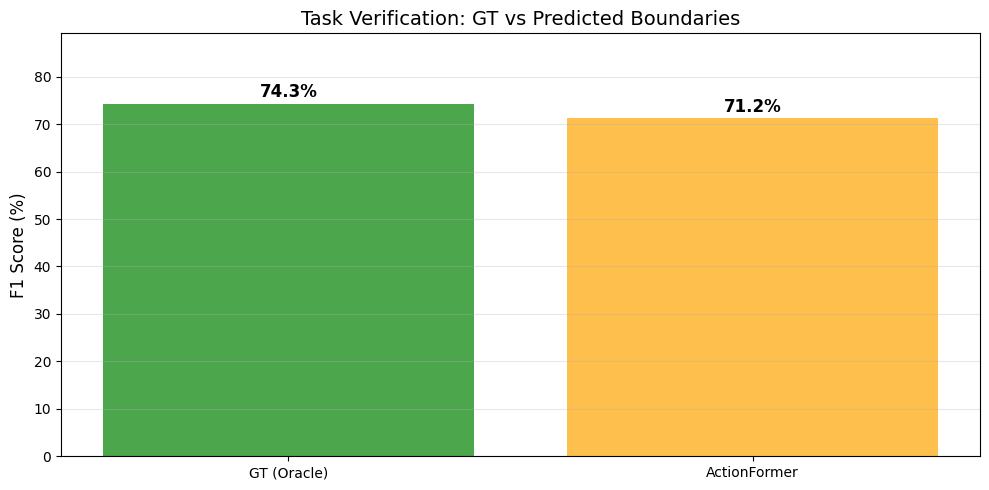


LaTeX Table Row for Report:
\begin{tabular}{lccc}
\toprule
Localization Method & F1 (\%) & Gap vs GT \\
\midrule
GT (Oracle) & 74.29 & - \\
ActionFormer & 71.23 & -3.1 \\
\bottomrule
\end{tabular}


In [38]:
# ==============================================================================
# COMPARE PIPELINE PERFORMANCE: GT vs PREDICTED BOUNDARIES
# ==============================================================================
import matplotlib.pyplot as plt

def quick_eval_method(data_path, model_class=MLPTaskVerifier, lr=1e-4,
                      batch_size=16, hidden_dim=256, num_epochs=20):
    """Quick evaluation of a dataset with best hyperparameters."""
    if not os.path.exists(data_path):
        return None

    with open(data_path, 'rb') as f:
        loaded = pickle.load(f)

    data = loaded['data']
    splits = loaded['splits']

    # Filter valid recordings
    train_ids = [r for r in splits['train'] if r in data]
    test_ids = [r for r in splits['test'] if r in data]

    if len(train_ids) == 0 or len(test_ids) == 0:
        return None

    # Get feature dimension
    sample_key = list(data.keys())[0]
    feat_dim = data[sample_key]['step_embeddings'].shape[1]

    # Create datasets
    train_dataset = TaskVerificationDataset(train_ids, data)
    test_dataset = TaskVerificationDataset(test_ids, data)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                             shuffle=False, collate_fn=collate_fn)

    # Create and train model
    model = model_class(feat_dim, hidden_dim=hidden_dim, dropout=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))

    # Train
    model.train()
    for epoch in range(num_epochs):
        for batch in train_loader:
            optimizer.zero_grad()
            emb = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(emb, mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            emb = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)

            logits = model(emb, mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_preds.extend(preds.flatten())
            all_labels.extend(batch['label'].numpy().flatten())

    from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

    return {
        'f1': f1_score(all_labels, all_preds),
        'accuracy': accuracy_score(all_labels, all_preds),
        'auc': roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.5,
        'method': loaded.get('method', 'unknown'),
        'n_test': len(test_ids)
    }


# Run comparison
print("=" * 70)
print("PIPELINE COMPARISON: GT vs PREDICTED BOUNDARIES")
print("=" * 70)

comparison_results = {}
methods_to_compare = [
    ("GT (Oracle)", "extension_data/step_embeddings_gt.pkl"),
    ("ActionFormer", "extension_data/step_embeddings_actionformer.pkl"),
    ("Clustering", "extension_data/step_embeddings_clustering.pkl"),
]

for method_name, data_path in methods_to_compare:
    print(f"\nEvaluating: {method_name}...")
    result = quick_eval_method(data_path)

    if result:
        comparison_results[method_name] = result
        print(f"  F1: {result['f1']*100:.2f}%")
        print(f"  Accuracy: {result['accuracy']*100:.1f}%")
        print(f"  AUC: {result['auc']*100:.1f}%")
    else:
        print(f"  ⚠️ Data not available")

# Visualization
if len(comparison_results) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))

    methods = list(comparison_results.keys())
    f1_scores = [comparison_results[m]['f1'] * 100 for m in methods]

    colors = ['green', 'orange', 'blue'][:len(methods)]
    bars = ax.bar(methods, f1_scores, color=colors, alpha=0.7)

    for bar, f1 in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{f1:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_ylabel('F1 Score (%)', fontsize=12)
    ax.set_title('Task Verification: GT vs Predicted Boundaries', fontsize=14)
    ax.set_ylim(0, max(f1_scores) * 1.2 if f1_scores else 100)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('extension_data/pipeline_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # LaTeX table
    print("\n" + "=" * 70)
    print("LaTeX Table Row for Report:")
    print("=" * 70)
    gt_f1 = comparison_results.get("GT (Oracle)", {}).get('f1', 0) * 100

    print(r"\begin{tabular}{lccc}")
    print(r"\toprule")
    print(r"Localization Method & F1 (\%) & Gap vs GT \\")
    print(r"\midrule")
    for method_name in methods:
        f1 = comparison_results[method_name]['f1'] * 100
        gap = f1 - gt_f1
        gap_str = f"{gap:+.1f}" if method_name != "GT (Oracle)" else "-"
        print(f"{method_name} & {f1:.2f} & {gap_str}" + r" \\")
    print(r"\bottomrule")
    print(r"\end{tabular}")
else:
    print("\n⚠️ Need at least 2 methods for comparison to generate plots.")